Imports

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from arch import arch_model
from arch.unitroot import PhillipsPerron
from mgarch import mgarch
import pickle

In [21]:
with open("../output/models/garch_results.pkl", "rb") as f:
    cond_vol_df = pickle.load(f)

Multicollinearity Check

         BTC    ETH  SP500    VTI    AGG    TLT
BTC    1.000  0.934 -0.031 -0.044 -0.391 -0.321
ETH    0.934  1.000 -0.086 -0.105 -0.424 -0.401
SP500 -0.031 -0.086  1.000  0.998  0.589  0.501
VTI   -0.044 -0.105  0.998  1.000  0.610  0.520
AGG   -0.391 -0.424  0.589  0.610  1.000  0.865
TLT   -0.321 -0.401  0.501  0.520  0.865  1.000


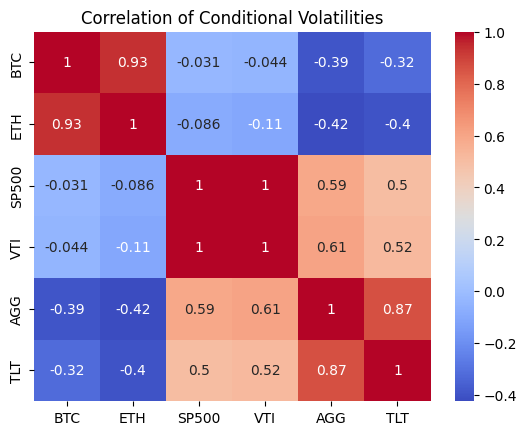

In [22]:
corr_matrix = cond_vol_df.corr()
print(corr_matrix.round(3))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation of Conditional Volatilities")
plt.show()

Conclusions:
- Core equities that need to be kept: BTC and ETH conditional volatilities are highly correlated (ρ ≈ 0.93). Results should be interpreted cautiously, as spillovers may reflect shared crypto‑market dynamics rather than distinct causal effects.
- Run 2 sets: (1) Full set (2) Reduced set (BTC, ETH, SP500, TLT).

## Stationarity Check (ADF Test)

In [23]:
def check_stationarity(cond_vol_df):
    results = []

    for col in cond_vol_df.columns:
        adf_result = adfuller(cond_vol_df[col])

        test_stat = adf_result[0]
        p_value = adf_result[1]

        if p_value < 0.01:
            sig = "***"
        elif p_value < 0.05:
            sig = "**"
        elif p_value < 0.10:
            sig = "*"
        else:
            sig = ""

        results.append([col, test_stat, p_value, sig])

    df_adf = pd.DataFrame(results,
                          columns=["Asset", "ADF Statistic", "p-value", "Sig"])

    df_adf["ADF Statistic"] = df_adf["ADF Statistic"].round(4)
    df_adf["p-value"] = df_adf["p-value"].round(6)

    return df_adf

check_stationarity(cond_vol_df)

,Asset,ADF Statistic,p-value,Sig
0,BTC,-2.0334,0.272112,
1,ETH,-2.2285,0.196062,
2,SP500,-6.2239,0.000000,***
3,VTI,-6.2222,0.000000,***
4,AGG,-5.4366,0.000003,***
5,TLT,-4.0378,0.001225,***


In [24]:
# taking log difference on series so that data is stationary
cond_vol_df = np.log(cond_vol_df).diff().dropna()*100
cond_vol_df

,BTC,ETH,SP500,VTI,AGG,TLT
date,,,,,,
2017-12-01,1.170181,-0.656657,-8.777444,-8.876602,-2.832274,-0.299414
2017-12-08,1.044101,1.081419,-9.123422,-8.369697,-1.349697,-1.146369
2017-12-15,0.976502,0.950805,-6.808426,-7.113403,-4.022926,-0.916793
2017-12-22,1.166562,-0.977887,-6.854497,-6.672021,1.388933,5.191019
2017-12-29,-6.036601,1.174962,-5.337196,-5.959755,22.788580,14.530704
...,...,...,...,...,...,...
2025-12-05,1.477643,1.090894,-12.282077,-10.587594,-1.400276,-0.484063
2025-12-12,-0.562176,1.776116,-8.197910,-8.636328,7.904342,5.638990
2025-12-19,1.582434,2.413887,3.455060,0.662722,-5.109575,-0.584653


In [25]:
# retest Stationarity (ADF)
check_stationarity(cond_vol_df)

,Asset,ADF Statistic,p-value,Sig
0,BTC,-21.2452,0.0,***
1,ETH,-22.0682,0.0,***
2,SP500,-19.7265,0.0,***
3,VTI,-19.6463,0.0,***
4,AGG,-13.3041,0.0,***
5,TLT,-13.0788,0.0,***


## VECTOR AUTOREGRESSION (VAR)

In [26]:
cond_vol_df.index = pd.to_datetime(cond_vol_df.index)

from statsmodels.tsa.api import VAR

model = VAR(cond_vol_df)
lag_selection = model.select_order(maxlags=8)
print(lag_selection.summary())

results = model.fit(lag_selection.aic)
print(results.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      18.13*      18.19*  7.464e+07*      18.15*
1       18.17       18.57   7.753e+07       18.33
2       18.21       18.97   8.114e+07       18.51
3       18.27       19.38   8.641e+07       18.71
4       18.36       19.81   9.405e+07       18.93
5       18.46       20.27   1.043e+08       19.18
6       18.51       20.67   1.099e+08       19.36
7       18.59       21.09   1.187e+08       19.58
8       18.60       21.46   1.209e+08       19.73
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 23, Apr, 2026
Time:                     17:36:49
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    18.1914
Nobs:                     423.000    

Conclusion: Optimal lag = 0

## GRANGER CAUSALITY TEST 
sensitivity test since granger test requires at least lag = 1

In [27]:
from statsmodels.tsa.stattools import grangercausalitytests
import itertools
import pandas as pd

max_lag = 1 
alpha = 0.05

def gc_test(max_lag, alpha):
    results_list = []

    columns = cond_vol_df.columns

    for y_col, x_col in itertools.permutations(columns, 2):
        test_result = grangercausalitytests(cond_vol_df[[y_col, x_col]], maxlag=max_lag, verbose=False)

        f_stat = test_result[max_lag][0]['ssr_ftest'][0]
        p_value = test_result[max_lag][0]['ssr_ftest'][1]

        # significance stars
        if p_value < 0.01:
            sig = "***"
        elif p_value < 0.05:
            sig = "**"
        elif p_value < 0.10:
            sig = "*"
        else:
            sig = ""

        results_list.append([x_col, y_col, f_stat, p_value, sig])

    df_results = pd.DataFrame(results_list, columns=["Cause", "Target", "F-stat", "p-value", "Sig"])

    print(df_results)

gc_test(max_lag, alpha)

    Cause Target    F-stat   p-value  Sig
0     ETH    BTC  0.923435  0.337129     
1   SP500    BTC  0.258410  0.611482     
2     VTI    BTC  0.239828  0.624587     
3     AGG    BTC  0.202076  0.653283     
4     TLT    BTC  0.632461  0.426904     
5     BTC    ETH  2.596060  0.107883     
6   SP500    ETH  2.390865  0.122801     
7     VTI    ETH  2.404900  0.121711     
8     AGG    ETH  1.554445  0.213177     
9     TLT    ETH  4.325442  0.038154   **
10    BTC  SP500  2.881731  0.090332    *
11    ETH  SP500  0.297804  0.585553     
12    VTI  SP500  0.286655  0.592656     
13    AGG  SP500  1.862697  0.173046     
14    TLT  SP500  2.398379  0.122216     
15    BTC    VTI  2.257969  0.133682     
16    ETH    VTI  0.174203  0.676617     
17  SP500    VTI  0.633709  0.426449     
18    AGG    VTI  1.273956  0.259672     
19    TLT    VTI  1.860018  0.173355     
20    BTC    AGG  1.438607  0.231043     
21    ETH    AGG  0.536991  0.464092     
22  SP500    AGG  5.524920  0.0192

/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/ts

In [28]:
from statsmodels.tsa.stattools import grangercausalitytests
import itertools
import pandas as pd

max_lag = 2
alpha = 0.05

def gc_test(max_lag, alpha):
    results_list = []

    columns = cond_vol_df.columns

    for y_col, x_col in itertools.permutations(columns, 2):
        test_result = grangercausalitytests(cond_vol_df[[y_col, x_col]], maxlag=max_lag, verbose=False)

        f_stat = test_result[max_lag][0]['ssr_ftest'][0]
        p_value = test_result[max_lag][0]['ssr_ftest'][1]

        # significance stars
        if p_value < 0.01:
            sig = "***"
        elif p_value < 0.05:
            sig = "**"
        elif p_value < 0.10:
            sig = "*"
        else:
            sig = ""

        results_list.append([x_col, y_col, f_stat, p_value, sig])

    df_results = pd.DataFrame(results_list, columns=["Cause", "Target", "F-stat", "p-value", "Sig"])

    print(df_results)

gc_test(max_lag, alpha)

    Cause Target    F-stat   p-value  Sig
0     ETH    BTC  0.586894  0.556511     
1   SP500    BTC  3.489624  0.031409   **
2     VTI    BTC  3.590598  0.028440   **
3     AGG    BTC  1.966608  0.141230     
4     TLT    BTC  2.328840  0.098677    *
5     BTC    ETH  1.306538  0.271864     
6   SP500    ETH  3.487263  0.031482   **
7     VTI    ETH  3.535118  0.030034   **
8     AGG    ETH  1.055622  0.348906     
9     TLT    ETH  2.602621  0.075285    *
10    BTC  SP500  1.427142  0.241166     
11    ETH  SP500  0.204401  0.815218     
12    VTI  SP500  0.388971  0.678000     
13    AGG  SP500  1.761276  0.173104     
14    TLT  SP500  1.459391  0.233565     
15    BTC    VTI  1.111169  0.330149     
16    ETH    VTI  0.141910  0.867741     
17  SP500    VTI  0.422434  0.655730     
18    AGG    VTI  1.242204  0.289816     
19    TLT    VTI  1.100416  0.333699     
20    BTC    AGG  0.938344  0.392102     
21    ETH    AGG  1.306541  0.271864     
22  SP500    AGG  8.581642  0.0002

/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/ts

In [29]:
from statsmodels.tsa.stattools import grangercausalitytests
import itertools
import pandas as pd

max_lag = 3
alpha = 0.05

results_list = []

columns = cond_vol_df.columns

gc_test(max_lag, alpha)

/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/ts

    Cause Target    F-stat   p-value  Sig
0     ETH    BTC  0.385366  0.763604     
1   SP500    BTC  3.783618  0.010637   **
2     VTI    BTC  3.994399  0.008000  ***
3     AGG    BTC  1.657969  0.175483     
4     TLT    BTC  1.641925  0.179074     
5     BTC    ETH  1.475135  0.220720     
6   SP500    ETH  2.537367  0.056240    *
7     VTI    ETH  2.675612  0.046858   **
8     AGG    ETH  1.249948  0.291248     
9     TLT    ETH  1.954837  0.120165     
10    BTC  SP500  1.110814  0.344443     
11    ETH  SP500  0.374827  0.771209     
12    VTI  SP500  0.360455  0.781600     
13    AGG  SP500  1.310256  0.270578     
14    TLT  SP500  1.146887  0.329882     
15    BTC    VTI  0.932484  0.424919     
16    ETH    VTI  0.347893  0.790698     
17  SP500    VTI  0.350271  0.788975     
18    AGG    VTI  0.914453  0.433877     
19    TLT    VTI  0.842825  0.471003     
20    BTC    AGG  0.465837  0.706276     
21    ETH    AGG  1.152625  0.327616     
22  SP500    AGG  6.101265  0.0004

/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/ts

## Reduced Set VAR and Granger Test
- Dropping VTI and AGG: SP500 and TLT already capture equity and bond dynamics.
- BTC–ETH redundancy remains (core to our research)
- acts as robustness check to full set

In [30]:
reduced_assets = ["BTC", "ETH", "SP500", "TLT"]
cond_vol_reduced = cond_vol_df[reduced_assets]

# VAR Lag
model_reduced = VAR(cond_vol_reduced)
lag_selection_reduced = model_reduced.select_order(maxlags=8)
print("\nLag Selection (Reduced Set):")
print(lag_selection_reduced.summary())

# fit IC preferred lag
results_reduced = model_reduced.fit(lag_selection_reduced.aic)
print("\nVAR Results (Reduced Set, IC-preferred lag):")
print(results_reduced.summary())

# Robustness check
for lag in [1, 2]:
    results = model_reduced.fit(lag)
    print(f"\nVAR({lag}) Results (Reduced Set):")
    print(results.summary())

# Granger causality tests: lags 1–3
def gc_test(data, max_lag, alpha=0.05):
    results_list = []
    for y_col, x_col in itertools.permutations(data.columns, 2):
        test_result = grangercausalitytests(data[[y_col, x_col]], maxlag=max_lag, verbose=False)
        f_stat = test_result[max_lag][0]['ssr_ftest'][0]
        p_value = test_result[max_lag][0]['ssr_ftest'][1]
        sig = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.10 else ""
        results_list.append([x_col, y_col, f_stat, p_value, sig])
    return pd.DataFrame(results_list, columns=["Cause", "Target", "F-stat", "p-value", "Sig"])

# Run Granger causality for lags 1–3
gc_results = {}
for lag in [1, 2, 3]:
    gc_results[lag] = gc_test(cond_vol_reduced, lag)

# Combine results into one table for comparison
combined_gc = pd.concat(gc_results, keys=[1, 2, 3], names=["Lag"])
print("\nGranger Causality Results (Reduced Set):")
print(combined_gc)



Lag Selection (Reduced Set):
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       12.54      12.57*   2.780e+05      12.55*
1      12.53*       12.73  2.776e+05*       12.61
2       12.55       12.90   2.822e+05       12.69
3       12.57       13.08   2.892e+05       12.77
4       12.61       13.27   3.005e+05       12.87
5       12.65       13.46   3.114e+05       12.97
6       12.66       13.63   3.148e+05       13.04
7       12.68       13.80   3.205e+05       13.12
8       12.70       13.98   3.282e+05       13.21
-------------------------------------------------

VAR Results (Reduced Set, IC-preferred lag):
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 23, Apr, 2026
Time:                     17:36:50
--------------------------------------------------------------------
No. of Equations:         4.00

/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/ts


Granger Causality Results (Reduced Set):
        Cause Target    F-stat   p-value  Sig
Lag                                          
1   0     ETH    BTC  0.923435  0.337129     
    1   SP500    BTC  0.258410  0.611482     
    2     TLT    BTC  0.632461  0.426904     
    3     BTC    ETH  2.596060  0.107883     
    4   SP500    ETH  2.390865  0.122801     
    5     TLT    ETH  4.325442  0.038154   **
    6     BTC  SP500  2.881731  0.090332    *
    7     ETH  SP500  0.297804  0.585553     
    8     TLT  SP500  2.398379  0.122216     
    9     BTC    TLT  1.817581  0.178330     
    10    ETH    TLT  1.412017  0.235395     
    11  SP500    TLT  5.533668  0.019116   **
2   0     ETH    BTC  0.586894  0.556511     
    1   SP500    BTC  3.489624  0.031409   **
    2     TLT    BTC  2.328840  0.098677    *
    3     BTC    ETH  1.306538  0.271864     
    4   SP500    ETH  3.487263  0.031482   **
    5     TLT    ETH  2.602621  0.075285    *
    6     BTC  SP500  1.427142  0.2411

/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/ts

Conclusions: dropping VTI and AGG didn’t distort the dynamics, but it did clean up redundancy.

### Importing Bubble Indicators

In [31]:
with open("../output/models/old_bubble_dummy.pkl", "rb") as f:
    bubble_dummy = pickle.load(f)

## VAR Model with Bubble–Volatility Interaction Terms

We estimate a VAR model of conditional volatilities, augmented with bubble–volatility interaction terms to capture regime-dependent effects during bubble periods in crypto markets.

### 1. Model Specification

- Endogenous variables: conditional volatilities of BTC, ETH, SP500, VTI, AGG, TLT  
- Exogenous variables: lagged interaction terms  
  - Bubble dummy × asset volatility for BTC and ETH  
- One-period lag is applied to exogenous variables to avoid look-ahead bias  

### 2. Lag Selection

The optimal lag order is selected using information criteria (AIC, BIC, HQIC, FPE), with most criteria favouring a VAR(0) specification.

### 3. Estimation Results

- Crypto bubble interaction terms are generally **statistically insignificant**
- Some weak negative effects on equity volatility (SP500, VTI), but not robust
- No meaningful impact detected on bond volatility (AGG, TLT)

### 4. Key Findings

- Strong contemporaneous correlation between BTC and ETH volatilities (~0.83)
- Equities (SP500, VTI) are nearly perfectly correlated in residuals (~0.99)
- Crypto is negatively correlated with equities and bonds
- Bond markets (AGG, TLT) exhibit strong internal correlation (~0.82)

### 5. Interpretation

- Bubble regimes in crypto do not show statistically significant spillover effects into broader asset volatility within this VAR specification
- Cross-asset volatility transmission is dominated by structural co-movement rather than bubble-driven dynamics

In [32]:
assets = cond_vol_df.columns
bubble_assets = ["BTC", "ETH"]

cond_vol_df_with_int = cond_vol_df.copy()
Y = cond_vol_df_with_int[assets]
X = pd.DataFrame(index=cond_vol_df_with_int.index)
for bubble_asset in bubble_assets:
    X[f'{bubble_asset}_bubble_x_{bubble_asset}_vol'] = (bubble_dummy[bubble_asset] * cond_vol_df_with_int[bubble_asset]).shift(1)

cleaned_data=pd.concat([Y,X], axis=1).dropna()
Y_clean = cleaned_data[assets]
X_clean = cleaned_data[X.columns]

model = VAR(endog=Y_clean, exog=X_clean)
lag_selection = model.select_order(maxlags=8)
print(lag_selection.summary())

results = model.fit(lag_selection.aic)
print(results.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      18.17*      18.35*  7.791e+07*      18.24*
1       18.21       18.74   8.100e+07       18.42
2       18.25       19.13   8.466e+07       18.60
3       18.32       19.54   9.002e+07       18.80
4       18.40       19.97   9.802e+07       19.02
5       18.50       20.43   1.088e+08       19.26
6       18.55       20.83   1.143e+08       19.45
7       18.63       21.25   1.237e+08       19.67
8       18.64       21.61   1.251e+08       19.81
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 23, Apr, 2026
Time:                     17:36:55
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    18.3570
Nobs:                     422.000    

## Diebold–Yilmaz Spillover Analysis

We compute volatility spillovers across assets using the Diebold–Yilmaz framework based on a VAR model and forecast error variance decomposition (FEVD).

### 1. Methodology

A VAR model is estimated on conditional volatilities, with lag length selected via AIC. The model is then used to compute FEVD over a multi-step horizon.

An optional exogenous term (e.g., bubble–volatility interaction) can be included, though the baseline specification uses a plain VAR.

### 2. Spillover Construction

From the FEVD matrix:

- Rows represent shock contributions **received**
- Columns represent shock contributions **transmitted**
- Values are normalised to sum to 100 per asset

We compute:

- Total spillover index: average cross-asset shock transmission  
- Directional to/from: shocks transmitted to and received from other assets  
- **Net spillovers**: difference between to and from  

### 3. Output

The function returns:

- FEVD spillover matrix  
- Total spillover index  
- Directional and net spillover measures  
- Estimated VAR model and selected lag order  

### 4. Interpretation

The total spillover index summarises the degree of interconnectedness across asset volatilities, with higher values indicating stronger cross-market volatility transmission.

In [33]:
def dy_spillover(df, exog=None, maxlags=8, horizon=10):
    """
    Diebold-Yilmaz Spillover Index with optional exogenous variables.

    Parameters
    ----------
    df : pd.DataFrame
        Endogenous variables (e.g., log-diff GARCH volatilities)
    exog : pd.DataFrame or None
        Optional exogenous variables (e.g., bubble × volatility interactions)
    maxlags : int
        Maximum lag to consider for VAR; optimal lag selected via AIC
    horizon : int
        Forecast horizon for FEVD

    Returns
    -------
    dict
        FEVD matrix, Total Spillover, Directional TO/FROM, Net Spillovers, VAR results
    """

    # 1. Fit VAR with optimal lag selection
    model = VAR(endog=df, exog=exog)
    lag_selection = model.select_order(maxlags)
    lag_order = max(int(lag_selection.aic), 1)
    results = model.fit(lag_order)

    # 2. Forecast error variance decomposition
    irf = results.irf(horizon)
    fevd = results.fevd(horizon)

    n = len(df.columns)
    theta = np.zeros((n, n))

    # 3. Build cumulative FEVD matrix (sum across horizon)
    for i in range(n):
        for j in range(n):
            theta[i, j] = fevd.decomp[i][:, j].sum()

    # 4. Normalize rows to sum to 100
    theta = 100 * theta / theta.sum(axis=1, keepdims=True)

    # 5. Total spillover index
    off_diag = theta.sum() - np.trace(theta)
    total_spill = off_diag / n

    # 6. Directional spillovers
    directional_to = theta.sum(axis=1) - np.diag(theta)
    directional_from = theta.sum(axis=0) - np.diag(theta)
    net_spill = directional_to - directional_from

    # 7. Wrap in nice DataFrames/Series
    names = df.columns
    spill_df = pd.DataFrame(theta, index=names, columns=names)

    return {
        "FEVD": spill_df,
        "Total Spillover": total_spill,
        "Directional TO": pd.Series(directional_to, index=names),
        "Directional FROM": pd.Series(directional_from, index=names),
        "Net Spillovers": pd.Series(net_spill, index=names),
        "VAR Results": results,
        "Lag Selected": lag_order
    }

In [34]:
spill_plain = dy_spillover(cond_vol_df, maxlags=8, horizon=10)
print("Total Spillover (plain VAR):", spill_plain["Total Spillover"])

Total Spillover (plain VAR): 42.76439889906078


In [35]:
spill_plain

{'FEVD':              BTC        ETH      SP500       VTI        AGG        TLT
 BTC    98.943166   0.208751   0.076629  0.004238   0.044178   0.723038
 ETH    66.914521  31.892332   0.447415  0.002271   0.197557   0.545904
 SP500   6.735953   1.123546  91.547312  0.088348   0.338890   0.165951
 VTI     6.866098   1.128945  90.244542  1.349865   0.249768   0.160781
 AGG     4.795561   0.471161   2.649324  2.640492  88.171521   1.271942
 TLT     1.360852   0.084254   5.197867  3.223247  58.624369  31.509411,
 'Total Spillover': 42.76439889906078,
 'Directional TO': BTC       1.056834
 ETH      68.107668
 SP500     8.452688
 VTI      98.650135
 AGG      11.828479
 TLT      68.490589
 dtype: float64,
 'Directional FROM': BTC      86.672985
 ETH       3.016658
 SP500    98.615776
 VTI       5.958596
 AGG      59.454762
 TLT       2.867616
 dtype: float64,
 'Net Spillovers': BTC     -85.616151
 ETH      65.091010
 SP500   -90.163088
 VTI      92.691539
 AGG     -47.626282
 TLT      65.62297

## Rolling Diebold–Yilmaz Spillover Analysis with Bubble Regimes

We analyse time-varying volatility spillovers using a rolling VAR-based Diebold–Yilmaz framework, and test whether spillovers differ during crypto bubble periods.

### 1. Data and Bubble Classification

- Sample: Weekly conditional volatilities (2017–2026)
- Assets: BTC, ETH, SP500, VTI, AGG, TLT
- Bubble periods identified using GSADF-based indicators
- Combined bubble regime: ~14% of sample

### 2. Rolling Spillover Estimation

- 52-week rolling VAR windows
- FEVD-based spillover computation
- Measures:
  - Crypto → Traditional spillover
  - Total system-wide connectedness
- Bubble dummy aligned within each rolling window

### 3. Key Empirical Results

- **Crypto → Traditional spillover**
  - Lower during bubble periods (6.29% → 5.15%)
  - Statistically significant (p = 0.0005)
  - Moderate effect size (Cohen’s d ≈ -0.35)

- **Total connectedness**
  - Decreases during bubble periods (51.6% → 47.4%)
  - Highly significant (p < 0.001)
  - Moderate effect size (Cohen’s d ≈ -0.54)

### 4. Interpretation

- Spillovers are **significantly lower during bubble regimes**
- Results are robust across parametric and non-parametric tests
- Contrary to the common intuition that bubbles increase contagion, crypto bubbles appear associated with **reduced cross-market transmission**

### 5. Robustness Check

- Cross-market correlations also lower during bubble periods
- Difference in correlations is not statistically significant
- Confirms that results are driven by spillover dynamics rather than simple correlation shifts

PART 1: SUMMARY OF DATA

Data loaded:
  Period: 2017-12-01 00:00:00 to 2026-01-02 00:00:00
  Observations: 423
  Assets: ['BTC', 'ETH', 'SP500', 'VTI', 'AGG', 'TLT']

Bubble periods detected:
  BTC: 45 weeks (10.6%)
  ETH: 34 weeks (8.0%)

Combined bubble indicator: 61 weeks (14.4%)

PART 2: ROLLING DIEBOLD-YILMAZ SPILLOVER INDEX

Computing rolling spillovers (window=52 weeks, 372 windows)...

SAMPLE SIZE CHECK
  Rolling windows WITH bubbles: 126 (33.9%)
  Rolling windows WITHOUT bubbles: 246 (66.1%)

  Sample size adequate for statistical testing

PART 3: BUBBLE ASSOCIATION ANALYSIS

────────────────────────────────────────────────────────────────────────────────
CRYPTO → TRADITIONAL SPILLOVER CHANNEL:
────────────────────────────────────────────────────────────────────────────────
  Normal periods: 6.29% (std=4.00)
  Bubble periods: 5.15% (std=2.24)
  Difference: -1.14%

────────────────────────────────────────────────────────────────────────────────
TOTAL SYSTEM-WIDE CONNECTEDNESS (

/var/folders/1c/spn47zsn3_db_xhyzhqzdrcw0000gn/T/ipykernel_77463/4238174918.py:297: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  normal_data_full = cond_vol_df[combined_bubble == 0][all_assets]
/var/folders/1c/spn47zsn3_db_xhyzhqzdrcw0000gn/T/ipykernel_77463/4238174918.py:298: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bubble_data_full = cond_vol_df[combined_bubble == 1][all_assets]



 Visualization saved as 'rolling_dy_bubble_analysis.png'

FINAL CONCLUSIONS

Based on the Rolling Diebold-Yilmaz Spillover Analysis:

────────────────────────────────────────────────────────────────────────────────
KEY EMPIRICAL FINDINGS:
────────────────────────────────────────────────────────────────────────────────

1. Crypto → Traditional Channel:
   • Normal periods: 6.29% (n=246)
   • Bubble periods: 5.15% (n=126)
   • Absolute difference: -1.14 pp
   • Relative difference: -18.1%

2. Total System-Wide Connectedness:
   • Normal periods: 51.57% (n=246)
   • Bubble periods: 47.41% (n=126)
   • Absolute difference: -4.17 pp
   • Relative difference: -8.1%

3. Statistical Significance:
   • Crypto → Traditional:
     - p-value: 0.0005
     - Bonferroni-adjusted (α=0.025): SIGNIFICANT
     - Cohen's d: -0.351
   • Total System-Wide:
     - p-value: 0.0000
     - Bonferroni-adjusted (α=0.025): SIGNIFICANT
     - Cohen's d: -0.538

 Could not export to Excel: If using all scalar value

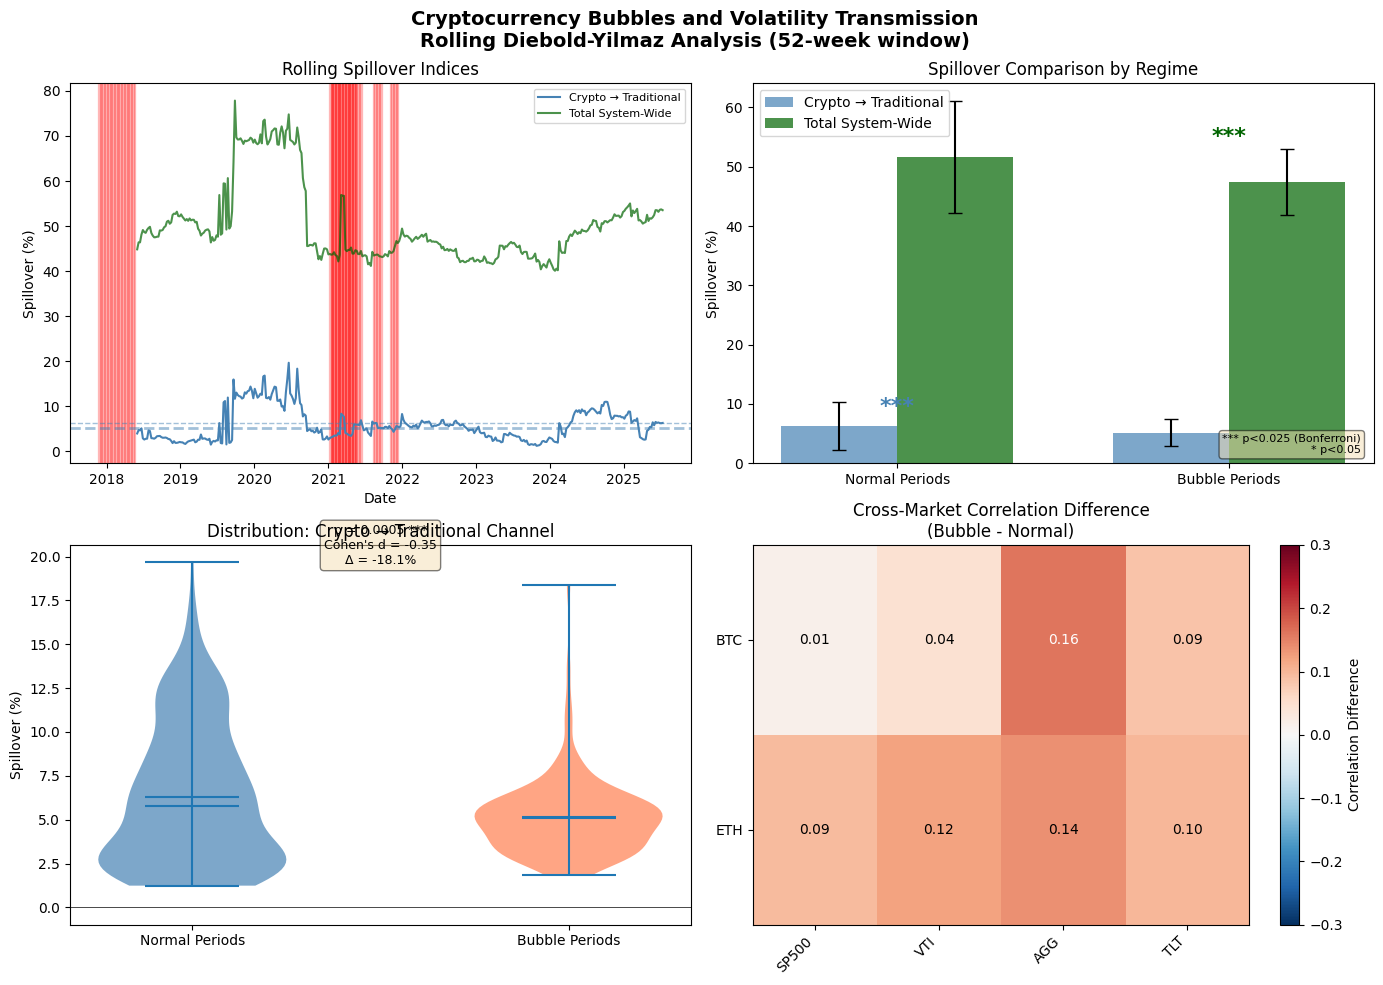

In [36]:
from scipy.stats import levene

# Summary of data
print("="*80)
print("PART 1: SUMMARY OF DATA")
print("="*80)

# Define asset groups
crypto = ["BTC", "ETH"]
traditional = ["SP500", "VTI", "AGG", "TLT"]
all_assets = crypto + traditional

print(f"\nData loaded:")
print(f"  Period: {cond_vol_df.index[0]} to {cond_vol_df.index[-1]}")
print(f"  Observations: {len(cond_vol_df)}")
print(f"  Assets: {all_assets}")

print(f"\nBubble periods detected:")
for asset in crypto:
    if asset in bubble_dummy.columns:
        n_bubbles = bubble_dummy[asset].sum()
        pct = 100 * n_bubbles / len(bubble_dummy)
        print(f"  {asset}: {n_bubbles} weeks ({pct:.1f}%)")

# Create combined bubble indicator (either BTC or ETH in bubble)
combined_bubble = (bubble_dummy[crypto].sum(axis=1) > 0).astype(int)
print(f"\nCombined bubble indicator: {combined_bubble.sum()} weeks ({100*combined_bubble.sum()/len(combined_bubble):.1f}%)")

# Rolling DY Spillover Index
print("\n" + "="*80)
print("PART 2: ROLLING DIEBOLD-YILMAZ SPILLOVER INDEX")
print("="*80)
def rolling_dy_spillover(df, window=52, maxlags=4, horizon=10):

    n_obs = len(df)
    n_windows = n_obs - window + 1
    
    rolling_spillovers = []
    print(f"\nComputing rolling spillovers (window={window} weeks, {n_windows} windows)...")
    
    for i in range(n_windows):
        
        window_data = df.iloc[i:i+window]
        window_date = df.index[i + window // 2]  # Center date
        
        # Check if any bubble occurred during this window
        window_bubble_dummy = bubble_dummy.iloc[i:i+window]
        # Sum across all crypto assets, then check if any week had a bubble
        window_has_bubble = int(window_bubble_dummy[crypto].sum(axis=1).max() > 0)
        
        try:
            # Fit VAR
            model = VAR(window_data)
            n_vars = len(window_data.columns)
            max_possible_lags = min(maxlags, (window - n_vars - 1) // n_vars)
            
            if max_possible_lags >= 1:
                lag_selection = model.select_order(maxlags=max_possible_lags)
                lag_order = max(1, lag_selection.aic if lag_selection.aic is not None else 1)
                
                results = model.fit(lag_order)
                
                # Compute FEVD
                fevd = results.fevd(horizon)
                
                n = len(window_data.columns)
                theta = np.zeros((n, n))
                
                # Build cumulative FEVD matrix
                for j in range(n):
                    for k in range(n):
                        theta[j, k] = fevd.decomp[j][:, k].sum()
                
                # Normalize rows to sum to 100
                theta = 100 * theta / theta.sum(axis=1, keepdims=True)
                
                # Total spillover index (system-wide connectedness)
                off_diag = theta.sum() - np.trace(theta)
                total_spill = off_diag / n
                
                # Directional spillover: crypto to traditional
                crypto_cols = [c for c in window_data.columns if c in crypto]
                trad_cols = [c for c in window_data.columns if c in traditional]
                
                crypto_idx = [list(window_data.columns).index(c) for c in crypto_cols]
                trad_idx = [list(window_data.columns).index(t) for t in trad_cols]
                
                crypto_to_trad = 0
                n_comparisons = 0
                for ci in crypto_idx:
                    for ti in trad_idx:
                        if ci != ti:
                            crypto_to_trad += theta[ti, ci]
                            n_comparisons += 1
                
                if n_comparisons > 0:
                    crypto_to_trad /= n_comparisons
                
                rolling_spillovers.append({
                    'date': window_date,
                    'total_spillover': total_spill,
                    'crypto_to_traditional': crypto_to_trad,
                    'bubble': window_has_bubble
                })
            else:
                rolling_spillovers.append({
                    'date': window_date,
                    'total_spillover': np.nan,
                    'crypto_to_traditional': np.nan,
                    'bubble': window_has_bubble
                })
        except Exception as e:
            print(f"Error at window {i}: {e}")
            rolling_spillovers.append({
                'date': window_date,
                'total_spillover': np.nan,
                'crypto_to_traditional': np.nan,
                'bubble': window_has_bubble
            })
    
    return pd.DataFrame(rolling_spillovers)

# Compute rolling spillovers
rolling_df = rolling_dy_spillover(
    cond_vol_df[all_assets], 
    window=52,  # 1-year rolling window
    maxlags=4, 
    horizon=10
)
# Drop NaN values
rolling_df = rolling_df.dropna()

n_bubble_windows = (rolling_df['bubble'] == 1).sum()
n_normal_windows = len(rolling_df) - n_bubble_windows
pct_bubble_windows = 100 * n_bubble_windows / len(rolling_df)

print(f"\n{'='*80}")
print("SAMPLE SIZE CHECK")
print(f"{'='*80}")
print(f"  Rolling windows WITH bubbles: {n_bubble_windows} ({pct_bubble_windows:.1f}%)")
print(f"  Rolling windows WITHOUT bubbles: {n_normal_windows} ({100-pct_bubble_windows:.1f}%)")

if n_bubble_windows < 20:
    print(f"\n CRITICAL WARNING: Only {n_bubble_windows} bubble windows!")
    print(f"  Statistical tests will have LOW POWER (high risk of Type II error).")
elif n_bubble_windows < 30:
    print(f"\n WARNING: Only {n_bubble_windows} bubble windows.")
    print(f"  Statistical tests may have limited power.")
else:
    print(f"\n  Sample size adequate for statistical testing")

# Comparing spillovers for bubble vs non-bubble periods
print("\n" + "="*80)
print("PART 3: BUBBLE ASSOCIATION ANALYSIS")
print("="*80)



# Split into bubble and normal periods for CRYPTO to TRADITIONAL channel
normal_spill = rolling_df[rolling_df['bubble'] == 0]['crypto_to_traditional']
bubble_spill = rolling_df[rolling_df['bubble'] == 1]['crypto_to_traditional']

# Total spillover comparison (system-wide connectedness)
normal_total = rolling_df[rolling_df['bubble'] == 0]['total_spillover']
bubble_total = rolling_df[rolling_df['bubble'] == 1]['total_spillover']

print(f"\n{'─'*80}")
print("CRYPTO → TRADITIONAL SPILLOVER CHANNEL:")
print(f"{'─'*80}")
print(f"  Normal periods: {normal_spill.mean():.2f}% (std={normal_spill.std():.2f})")
print(f"  Bubble periods: {bubble_spill.mean():.2f}% (std={bubble_spill.std():.2f})")
print(f"  Difference: {bubble_spill.mean() - normal_spill.mean():+.2f}%")

print(f"\n{'─'*80}")
print("TOTAL SYSTEM-WIDE CONNECTEDNESS (All Assets):")
print(f"{'─'*80}")
print(f"  Normal periods: {normal_total.mean():.2f}% (std={normal_total.std():.2f})")
print(f"  Bubble periods: {bubble_total.mean():.2f}% (std={bubble_total.std():.2f})")
print(f"  Difference: {bubble_total.mean() - normal_total.mean():+.2f}%")

# Statistical tests for both measures
from scipy.stats import ttest_ind, mannwhitneyu

# Crypto → Traditional channel
t_stat_ct, t_pval_ct = ttest_ind(normal_spill, bubble_spill, equal_var=False)
u_stat_ct, u_pval_ct = mannwhitneyu(normal_spill, bubble_spill, alternative='two-sided')

# Total spillover
t_stat_total, t_pval_total = ttest_ind(normal_total, bubble_total, equal_var=False)
u_stat_total, u_pval_total = mannwhitneyu(normal_total, bubble_total, alternative='two-sided')

# Effect size (Cohen's d) for crypto → traditional
pooled_std_ct = np.sqrt((normal_spill.std()**2 + bubble_spill.std()**2) / 2)
cohens_d_ct = (bubble_spill.mean() - normal_spill.mean()) / pooled_std_ct if pooled_std_ct > 0 else 0

# Effect size for total spillover
pooled_std_total = np.sqrt((normal_total.std()**2 + bubble_total.std()**2) / 2)
cohens_d_total = (bubble_total.mean() - normal_total.mean()) / pooled_std_total if pooled_std_total > 0 else 0

# Economic significance interpretation
pct_increase_ct = 100 * (bubble_spill.mean() - normal_spill.mean()) / normal_spill.mean()
pct_increase_total = 100 * (bubble_total.mean() - normal_total.mean()) / normal_total.mean()

print(f"\n{'─'*80}")
print("STATISTICAL TESTS:")
print(f"{'─'*80}")
print(f"\nCrypto → Traditional Channel:")
print(f"  T-test: t={t_stat_ct:.3f}, p={t_pval_ct:.4f}")
print(f"  Mann-Whitney U: U={u_stat_ct:.0f}, p={u_pval_ct:.4f}")
print(f"  Cohen's d effect size: {cohens_d_ct:.3f}")
print(f"  Economic significance:")
print(f"    Absolute increase: {bubble_spill.mean() - normal_spill.mean():+.2f} percentage points")
print(f"    Relative increase: {pct_increase_ct:+.1f}%")
if abs(pct_increase_ct) < 10:
    print(f"    Small economic magnitude (<10%)")
elif abs(pct_increase_ct) < 25:
    print(f"    Moderate economic magnitude (10-25%)")
else:
    print(f"    Large economic magnitude (>25%)")

print(f"\nTotal System-Wide Connectedness:")
print(f"  T-test: t={t_stat_total:.3f}, p={t_pval_total:.4f}")
print(f"  Mann-Whitney U: U={u_stat_total:.0f}, p={u_pval_total:.4f}")
print(f"  Cohen's d effect size: {cohens_d_total:.3f}")
print(f"  Economic significance:")
print(f"    Absolute increase: {bubble_total.mean() - normal_total.mean():+.2f} percentage points")
print(f"    Relative increase: {pct_increase_total:+.1f}%")
if abs(pct_increase_total) < 10:
    print(f"    → Small economic magnitude (<10%)")
elif abs(pct_increase_total) < 25:
    print(f"    → Moderate economic magnitude (10-25%)")
else:
    print(f"    → Large economic magnitude (>25%)")

# Bonferroni correction
n_primary_tests = 2  # Two main hypotheses: crypto→trad and total spillover
bonferroni_alpha = 0.05 / n_primary_tests

print(f"\n{'─'*80}")
print("MULTIPLE TESTING CORRECTION (Bonferroni):")
print(f"{'─'*80}")
print(f"  Number of primary tests: {n_primary_tests}")
print(f"  Original α = 0.05")
print(f"  Bonferroni-adjusted α = {bonferroni_alpha:.4f}")
print(f"\n  Results with adjusted threshold:")
print(f"    Crypto→Traditional significant: {t_pval_ct < bonferroni_alpha} (p={t_pval_ct:.4f})")
print(f"    Total spillover significant: {t_pval_total < bonferroni_alpha} (p={t_pval_total:.4f})")

# Check variance homogeneity (validates Welch's t-test use)
lev_stat_ct, lev_pval_ct = levene(normal_spill, bubble_spill)
lev_stat_total, lev_pval_total = levene(normal_total, bubble_total)

print(f"\n{'─'*80}")
print("VARIANCE HOMOGENEITY CHECK (Levene's Test):")
print(f"{'─'*80}")
print(f"  Crypto→Traditional: F={lev_stat_ct:.3f}, p={lev_pval_ct:.4f}")
if lev_pval_ct < 0.05:
    print(f"    - Variances differ; Welch's t-test (already used) is appropriate ✓")
else:
    print(f"    - Equal variances; Welch's t-test is conservative (appropriate)")

print(f"  Total spillover: F={lev_stat_total:.3f}, p={lev_pval_total:.4f}")
if lev_pval_total < 0.05:
    print(f"    - Variances differ; Welch's t-test (already used) is appropriate ✓")
else:
    print(f"    - Equal variances; Welch's t-test is conservative (appropriate)")

# Interpretation (careful wording - association, not causation)
print(f"\n{'─'*80}")
print("ASSOCIATION ASSESSMENT:")
print(f"{'─'*80}")

# Use Bonferroni-adjusted alpha for interpretation
if t_pval_ct < bonferroni_alpha and bubble_spill.mean() > normal_spill.mean():
    print(f"\n  Spillovers are significantly HIGHER during bubble periods (Bonferroni-adjusted)")
    print(f"    Suggests bubbles are associated with stronger cross-market transmission")
    print(f"    Effect size: {cohens_d_ct:.3f} ({'large' if abs(cohens_d_ct) > 0.8 else 'medium' if abs(cohens_d_ct) > 0.5 else 'small'})")
    print(f"    Economic magnitude: {abs(pct_increase_ct):.1f}% increase")
elif t_pval_ct < 0.05 and bubble_spill.mean() > normal_spill.mean():
    print(f"\n  Spillovers are higher during bubble periods (p={t_pval_ct:.4f})")
    print(f"    Significant at 5% level but NOT at Bonferroni-adjusted level")
    print(f"    Suggestive evidence, but should be interpreted cautiously")
elif t_pval_ct < bonferroni_alpha:
    print(f"\n  Spillovers are significantly LOWER during bubble periods")
else:
    print(f"\n  No statistically significant difference (p={t_pval_ct:.4f})")
    print(f"    Either no real difference OR insufficient power to detect it")


    
# Regime Splitting for Robustness
print("\n" + "="*80)
print("PART 4: REGIME-SPLITTING VAR (Robustness Check)")
print("="*80)

# Split full sample
normal_data_full = cond_vol_df[combined_bubble == 0][all_assets]
bubble_data_full = cond_vol_df[combined_bubble == 1][all_assets]

print(f"\nNormal periods: {len(normal_data_full)} weeks")
print(f"Bubble periods: {len(bubble_data_full)} weeks")

if len(bubble_data_full) < 30:
    print(f"\n  CAUTION: Bubble subsample has only {len(bubble_data_full)} observations.")
    print(f"  Results from regime-specific models may be unreliable.")


# Calculate cross-market correlation (dependence) for each regime
regime_results = []

for data, name in [(normal_data_full, "Normal"), (bubble_data_full, "Bubble")]:
    if len(data) > 20:
        # Cross-market correlation (dependence)
        crypto_trad_corrs = []
        for cryp in crypto:
            for trad in traditional:
                if cryp in data.columns and trad in data.columns:
                    corr = data[cryp].corr(data[trad])
                    crypto_trad_corrs.append(corr)
        
        avg_corr = np.mean(crypto_trad_corrs)
        
        regime_results.append({
            'Regime': name,
            'Avg_CrossMarket_Correlation': avg_corr,
            'Observations': len(data)
        })
        
        print(f"\n  {name} Periods:")
        print(f"    Avg crypto-traditional cross-market correlation: {avg_corr:.4f}")

if len(regime_results) == 2:
    corr_diff = regime_results[1]['Avg_CrossMarket_Correlation'] - regime_results[0]['Avg_CrossMarket_Correlation']
    print(f"\n  Correlation Difference (Bubble - Normal): {corr_diff:+.4f}")
    
    # Fisher's z-test for correlation difference
    def fisher_z_test(r1, r2, n1, n2):
        z1 = np.arctanh(r1)
        z2 = np.arctanh(r2)
        se = np.sqrt(1/(n1-3) + 1/(n2-3))
        z_stat = (z1 - z2) / se
        p_val = 2 * (1 - stats.norm.cdf(abs(z_stat)))
        return z_stat, p_val
    
    z_stat, z_pval = fisher_z_test(
        regime_results[0]['Avg_CrossMarket_Correlation'],
        regime_results[1]['Avg_CrossMarket_Correlation'],
        regime_results[0]['Observations'],
        regime_results[1]['Observations']
    )
    
    print(f"  Fisher's z-test: z={z_stat:.3f}, p={z_pval:.4f}")
    
    if z_pval < 0.05 and corr_diff > 0:
        print(f"  - Robustness check confirms higher dependence during bubble periods")
    elif z_pval >= 0.05:
        print(f"  - Correlation difference not statistically significant")



# Visualization

print("\n" + "="*80)
print("PART 5: VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cryptocurrency Bubbles and Volatility Transmission\nRolling Diebold-Yilmaz Analysis (52-week window)', 
             fontsize=14, fontweight='bold')

# Plot 1: Rolling Spillover Over Time (Both measures)
ax1 = axes[0, 0]
ax1.plot(rolling_df['date'], rolling_df['crypto_to_traditional'], 
         color='steelblue', linewidth=1.5, label='Crypto → Traditional')
ax1.plot(rolling_df['date'], rolling_df['total_spillover'], 
         color='darkgreen', linewidth=1.5, label='Total System-Wide', alpha=0.7)
ax1.set_ylabel('Spillover (%)')
ax1.set_xlabel('Date')
ax1.set_title('Rolling Spillover Indices')
ax1.axhline(y=normal_spill.mean(), color='steelblue', linestyle='--', alpha=0.5, linewidth=1)
ax1.axhline(y=bubble_spill.mean(), color='steelblue', linestyle='--', alpha=0.5, linewidth=2)
ax1.legend(loc='upper right', fontsize=8)

# Highlight bubble periods
for cryp in crypto:
    if cryp in bubble_dummy.columns:
        bubble_periods = bubble_dummy[cryp] == 1
        bubble_dates = bubble_dummy.index[bubble_periods]
        for date in bubble_dates:
            ax1.axvspan(date - pd.Timedelta(days=3.5), date + pd.Timedelta(days=3.5), 
                       alpha=0.2, color='red', label=f'{cryp} bubble' if date == bubble_dates[0] else '')

# Plot 2: Bar Chart Comparison (Both measures)
ax2 = axes[0, 1]
x = np.arange(2)
width = 0.35

crypto_trad_means = [normal_spill.mean(), bubble_spill.mean()]
total_means = [normal_total.mean(), bubble_total.mean()]

bars1 = ax2.bar(x - width/2, crypto_trad_means, width, label='Crypto → Traditional', 
                color='steelblue', alpha=0.7, yerr=[normal_spill.std(), bubble_spill.std()], capsize=5)
bars2 = ax2.bar(x + width/2, total_means, width, label='Total System-Wide', 
                color='darkgreen', alpha=0.7, yerr=[normal_total.std(), bubble_total.std()], capsize=5)

ax2.set_xticks(x)
ax2.set_xticklabels(['Normal Periods', 'Bubble Periods'])
ax2.set_ylabel('Spillover (%)')
ax2.set_title('Spillover Comparison by Regime')
ax2.legend()
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add significance annotations (use Bonferroni-adjusted threshold)
if t_pval_ct < bonferroni_alpha:
    y_pos = max(crypto_trad_means[1] + bubble_spill.std() + 1, crypto_trad_means[1] * 1.1)
    ax2.text(0, y_pos, '***', ha='center', fontsize=16, fontweight='bold', color='steelblue')
elif t_pval_ct < 0.05:
    y_pos = max(crypto_trad_means[1] + bubble_spill.std() + 1, crypto_trad_means[1] * 1.1)
    ax2.text(0, y_pos, '*', ha='center', fontsize=14, fontweight='bold', color='steelblue')

if t_pval_total < bonferroni_alpha:
    y_pos = max(total_means[1] + bubble_total.std() + 1, total_means[1] * 1.1)
    ax2.text(1, y_pos, '***', ha='center', fontsize=16, fontweight='bold', color='darkgreen')
elif t_pval_total < 0.05:
    y_pos = max(total_means[1] + bubble_total.std() + 1, total_means[1] * 1.1)
    ax2.text(1, y_pos, '*', ha='center', fontsize=14, fontweight='bold', color='darkgreen')

# Add legend for significance
ax2.text(0.98, 0.02, '*** p<0.025 (Bonferroni)\n* p<0.05', 
         transform=ax2.transAxes, ha='right', va='bottom', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 3: Distribution Comparison (Violin Plot) - Crypto → Traditional
ax3 = axes[1, 0]
data_to_plot = [normal_spill.values, bubble_spill.values]
parts = ax3.violinplot(data_to_plot, positions=[0, 1], showmeans=True, showmedians=True)
parts['bodies'][0].set_facecolor('steelblue')
parts['bodies'][1].set_facecolor('coral')
parts['bodies'][0].set_alpha(0.7)
parts['bodies'][1].set_alpha(0.7)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Normal Periods', 'Bubble Periods'])
ax3.set_ylabel('Spillover (%)')
ax3.set_title('Distribution: Crypto → Traditional Channel')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add statistical annotation
sig_marker = "***" if t_pval_ct < bonferroni_alpha else "*" if t_pval_ct < 0.05 else "n.s."
ax3.text(0.5, 0.95, f"p = {t_pval_ct:.4f} {sig_marker}\nCohen's d = {cohens_d_ct:.2f}\nΔ = {pct_increase_ct:+.1f}%", 
         transform=ax3.transAxes, ha='center', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 4: Cross-Market Correlation Heatmap
ax4 = axes[1, 1]
if len(normal_data_full) > 0 and len(bubble_data_full) > 0:
    corr_normal = normal_data_full[crypto + traditional].corr()
    corr_bubble = bubble_data_full[crypto + traditional].corr()
    corr_diff = corr_bubble - corr_normal
    
    # Focus on crypto-traditional block
    crypto_idx = range(len(crypto))
    trad_idx = range(len(crypto), len(crypto + traditional))
    diff_block = corr_diff.iloc[crypto_idx, trad_idx]
    
    im = ax4.imshow(diff_block.values, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)
    ax4.set_xticks(range(len(traditional)))
    ax4.set_yticks(range(len(crypto)))
    ax4.set_xticklabels(traditional, rotation=45, ha='right')
    ax4.set_yticklabels(crypto)
    ax4.set_title('Cross-Market Correlation Difference\n(Bubble - Normal)')
    plt.colorbar(im, ax=ax4, label='Correlation Difference')
    
    # Add text annotations
    for i in range(len(crypto)):
        for j in range(len(traditional)):
            val = diff_block.iloc[i, j]
            text_color = "white" if abs(val) > 0.15 else "black"
            ax4.text(j, i, f'{val:.2f}', ha="center", va="center", color=text_color, fontsize=10)

plt.tight_layout()
plt.savefig('../output/figures/rolling_dy_bubble_analysis.png', dpi=300, bbox_inches='tight')
print("\n Visualization saved as 'rolling_dy_bubble_analysis.png'")

# Final Conclusions

print("\n" + "="*80)
print("FINAL CONCLUSIONS")
print("="*80)

print("\nBased on the Rolling Diebold-Yilmaz Spillover Analysis:")

print(f"\n{'─'*80}")
print("KEY EMPIRICAL FINDINGS:")
print(f"{'─'*80}")

print(f"\n1. Crypto → Traditional Channel:")
print(f"   • Normal periods: {normal_spill.mean():.2f}% (n={len(normal_spill)})")
print(f"   • Bubble periods: {bubble_spill.mean():.2f}% (n={len(bubble_spill)})")
print(f"   • Absolute difference: {bubble_spill.mean() - normal_spill.mean():+.2f} pp")
print(f"   • Relative difference: {pct_increase_ct:+.1f}%")

print(f"\n2. Total System-Wide Connectedness:")
print(f"   • Normal periods: {normal_total.mean():.2f}% (n={len(normal_total)})")
print(f"   • Bubble periods: {bubble_total.mean():.2f}% (n={len(bubble_total)})")
print(f"   • Absolute difference: {bubble_total.mean() - normal_total.mean():+.2f} pp")
print(f"   • Relative difference: {pct_increase_total:+.1f}%")

print(f"\n3. Statistical Significance:")
print(f"   • Crypto → Traditional:")
print(f"     - p-value: {t_pval_ct:.4f}")
print(f"     - Bonferroni-adjusted (α=0.025): {'SIGNIFICANT' if t_pval_ct < bonferroni_alpha else 'not significant'}")
print(f"     - Cohen's d: {cohens_d_ct:.3f}")
print(f"   • Total System-Wide:")
print(f"     - p-value: {t_pval_total:.4f}")
print(f"     - Bonferroni-adjusted (α=0.025): {'SIGNIFICANT' if t_pval_total < bonferroni_alpha else 'not significant'}")
print(f"     - Cohen's d: {cohens_d_total:.3f}")

# Export results
try:
    with pd.ExcelWriter('../output/tables/rolling_dy_results.xlsx') as writer:
        rolling_df.to_excel(writer, sheet_name='Rolling_Spillovers', index=False)
        if gc_results:
            pd.DataFrame(gc_results).to_excel(writer, sheet_name='Granger_Causality', index=False)
        
        # Summary statistics (EXPANDED)
        summary_df = pd.DataFrame({
            'Metric': ['Crypto_Trad_Normal_Mean', 'Crypto_Trad_Bubble_Mean', 
                       'Crypto_Trad_Difference_Absolute', 'Crypto_Trad_Difference_Relative_Pct',
                       'Crypto_Trad_T_Stat', 'Crypto_Trad_P_Value', 
                       'Crypto_Trad_P_Value_Bonferroni_Adjusted',
                       'Crypto_Trad_Cohen_d',
                       'Total_Normal_Mean', 'Total_Bubble_Mean', 
                       'Total_Difference_Absolute', 'Total_Difference_Relative_Pct',
                       'Total_T_Stat', 'Total_P_Value',
                       'Total_P_Value_Bonferroni_Adjusted',
                       'Total_Cohen_d',
                       'N_Normal_Windows', 'N_Bubble_Windows',
                       'Bonferroni_Alpha'],
            'Value': [normal_spill.mean(), bubble_spill.mean(), 
                      bubble_spill.mean() - normal_spill.mean(),
                      pct_increase_ct,
                      t_stat_ct, t_pval_ct, bonferroni_alpha,
                      cohens_d_ct,
                      normal_total.mean(), bubble_total.mean(),
                      bubble_total.mean() - normal_total.mean(),
                      pct_increase_total,
                      t_stat_total, t_pval_total, bonferroni_alpha,
                      cohens_d_total,
                      len(normal_spill), len(bubble_spill),
                      bonferroni_alpha]
        })
        summary_df.to_excel(writer, sheet_name='Summary', index=False)
    
    print("\n Results exported to 'rolling_dy_results.xlsx'")
except Exception as e:
    print(f"\n Could not export to Excel: {e}")
    


## Granger Causality Tests (Not Used in Analysis)

In [37]:
print("\n" + "="*80)
print("GRANGER CAUSALITY TESTS (Exploratory Analysis)")
print("="*80)
print("NOTE: Results are exploratory due to small bubble subsample")

gc_results = []

# FIX 5: IMPROVED GRANGER CAUSALITY LAG SELECTION
# Use lag = 2 for weekly data (captures 2-week transmission)
FIXED_LAG = 2  # Changed from 1 to capture longer transmission lags

print(f"\nUsing fixed lag = {FIXED_LAG} (appropriate for weekly data)")
print("  Rationale: Weekly data often shows spillovers at 2-4 week horizons")
print("             Fixed lag avoids post-selection bias")

for period_type, mask in [('Normal', combined_bubble == 0), 
                           ('Bubble', combined_bubble == 1)]:
    
    period_data = cond_vol_df[mask]
    
    if len(period_data) < 30:
        print(f"\n{period_type} periods: Too few observations ({len(period_data)}) - skipping")
        continue
    
    print(f"\n{period_type.upper()} PERIODS (n={len(period_data)})")
    
    gc_count = 0
    for cryp in crypto:
        for trad in traditional:
            if cryp in period_data.columns and trad in period_data.columns:
                try:
                    test_data = period_data[[trad, cryp]].dropna()
                    
                    # Check minimum sample size for lag=2
                    if len(test_data) > FIXED_LAG * 5 + 10:  # Need at least 5*lag + buffer
                        gc_test = grangercausalitytests(test_data, maxlag=FIXED_LAG, verbose=False)
                        
                        pval = gc_test[FIXED_LAG][0]['ssr_ftest'][1]
                        fstat = gc_test[FIXED_LAG][0]['ssr_ftest'][0]
                        is_sig = pval < 0.05
                        
                        if is_sig:
                            gc_count += 1
                        
                        gc_results.append({
                            'Period': period_type,
                            'Cause': cryp,
                            'Target': trad,
                            'Lag': FIXED_LAG,
                            'F_stat': fstat,
                            'P_value': pval,
                            'Significant': is_sig
                        })
                except Exception as e:
                    pass
    
    total_possible = len(crypto) * len(traditional)
    print(f"  Significant Granger causality (lag={FIXED_LAG}): {gc_count}/{total_possible}")

# Summary with caveat
if gc_results:
    gc_df = pd.DataFrame(gc_results)
    normal_gc = len(gc_df[(gc_df['Period'] == 'Normal') & (gc_df['Significant'])])
    bubble_gc = len(gc_df[(gc_df['Period'] == 'Bubble') & (gc_df['Significant'])])
    
    print(f"\n{'─'*80}")
    print("EXPLORATORY GRANGER CAUSALITY SUMMARY:")
    print(f"{'─'*80}")
    print(f"  Normal periods: {normal_gc} significant relationships")
    print(f"  Bubble periods: {bubble_gc} significant relationships")
    print(f"\n  NOTE: Results are exploratory due to small bubble subsample.")
    print(f"  Fixed lag = {FIXED_LAG} used to avoid post-selection bias.")
    print(f"  No multiple testing correction applied (exploratory analysis).")


GRANGER CAUSALITY TESTS (Exploratory Analysis)
NOTE: Results are exploratory due to small bubble subsample

Using fixed lag = 2 (appropriate for weekly data)
  Rationale: Weekly data often shows spillovers at 2-4 week horizons
             Fixed lag avoids post-selection bias

NORMAL PERIODS (n=363)
  Significant Granger causality (lag=2): 0/8

BUBBLE PERIODS (n=60)
  Significant Granger causality (lag=2): 0/8

────────────────────────────────────────────────────────────────────────────────
EXPLORATORY GRANGER CAUSALITY SUMMARY:
────────────────────────────────────────────────────────────────────────────────
  Normal periods: 0 significant relationships
  Bubble periods: 0 significant relationships

  NOTE: Results are exploratory due to small bubble subsample.
  Fixed lag = 2 used to avoid post-selection bias.
  No multiple testing correction applied (exploratory analysis).


/var/folders/1c/spn47zsn3_db_xhyzhqzdrcw0000gn/T/ipykernel_77463/337035868.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  period_data = cond_vol_df[mask]
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmod